# Test d'installation CLIMADA — pipeline complet Hazard x Exposure x Vulnerability -> Loss

Objectif de ce notebook : **valider que CLIMADA fonctionne**, pas encore travailler sur Paris/inondation.

On utilise le jeu de données de démonstration fourni avec CLIMADA (aucun téléchargement réseau nécessaire, tourne en quelques secondes) : un péril **cyclone tropical** sur la **Floride**, avec une exposition (bâti) et une fonction de vulnérabilité déjà appariées par les développeurs de CLIMADA. C'est le "hello world" historique de l'outil.

Les 4 briques qu'on va manipuler, dans l'ordre :
1. **Hazard** — où/quand/intensité de l'événement (ici : 216 trajectoires de cyclones simulées sur la Floride, 1990-2004)
2. **Exposures** — ce qui est exposé et sa valeur (ici : valeur du bâti en dollars, sur une grille couvrant la Floride)
3. **ImpactFuncSet** — la fonction de vulnérabilité (courbe qui dit : "à telle vitesse de vent, tel % de dommage")
4. **Impact** — le résultat final : la perte calculée en combinant les 3 briques ci-dessus

In [1]:
# On désactive les warnings verbeux de CLIMADA pour garder une sortie lisible
import warnings
warnings.filterwarnings("ignore")

from climada.hazard import Hazard
from climada.entity import Entity
from climada.engine import ImpactCalc
from climada.util.constants import HAZ_DEMO_H5, ENT_DEMO_TODAY

print("Import climada OK")

Import climada OK


## 1. Charger l'aléa (Hazard)

`Hazard.from_hdf5(...)` charge un fichier déjà pré-calculé (format `.h5`, standard pour les données scientifiques volumineuses). Concrètement, l'objet `Hazard` contient une **matrice** : en ligne, chaque événement (216 trajectoires de cyclones différentes) ; en colonne, chaque point de la grille géographique. Chaque case = l'intensité (vitesse de vent en m/s) que CET événement produirait à CE point s'il se produisait.

In [2]:
haz = Hazard.from_hdf5(HAZ_DEMO_H5)
print(f"Type de péril : {haz.haz_type}")
print(f"Nombre d'événements simulés : {haz.event_id.size}")
print(f"Nombre de points de la grille : {haz.centroids.size}")
print(f"Intensité max observée (tous événements confondus) : {haz.intensity.max():.1f} m/s")

Type de péril : TC
Nombre d'événements simulés : 216
Nombre de points de la grille : 2500
Intensité max observée (tous événements confondus) : 72.7 m/s


<GeoAxes: title={'center': 'TC max intensity at each point'}>

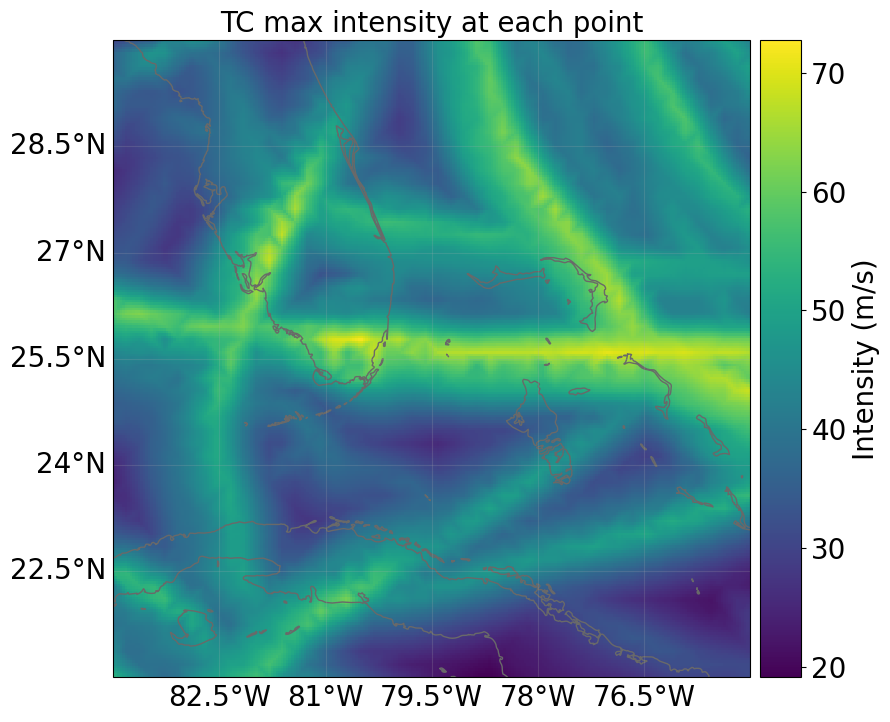

In [3]:
# Carte de l'intensité maximale atteinte à chaque point de la grille, tous événements confondus
haz.plot_intensity(event=0)  # event=0 signifie ici "agrège tous les événements, prends le max par point"

## 2. Charger l'exposition et la vulnérabilité (Entity)

Un objet `Entity` regroupe plusieurs briques d'un coup : ici on récupère `exposures` (valeur du bâti par point de grille) et `impact_funcs` (la fonction de vulnérabilité). C'est un fichier Excel de démo fourni par CLIMADA, construit spécifiquement pour être compatible avec le hazard chargé au-dessus (mêmes points de grille).

In [4]:
ent = Entity.from_excel(ENT_DEMO_TODAY)
ent.exposures.gdf.head()

,value,deductible,cover,impf_TC,Value_2010,geometry
0,1.392750e+10,0,1.392750e+10,1,5.139301e+09,POINT (-80.1288 26.9339)
1,1.259606e+10,0,1.259606e+10,1,4.647994e+09,POINT (-80.09828 26.9572)
2,1.259606e+10,0,1.259606e+10,1,4.647994e+09,POINT (-80.74895 26.78385)
3,1.259606e+10,0,1.259606e+10,1,4.647994e+09,POINT (-80.5507 26.64552)
4,1.259606e+10,0,1.259606e+10,1,4.647994e+09,POINT (-80.59693 26.8978)


Valeur totale exposée (bâti) : 657,053,294,560 USD


<GeoAxes: >

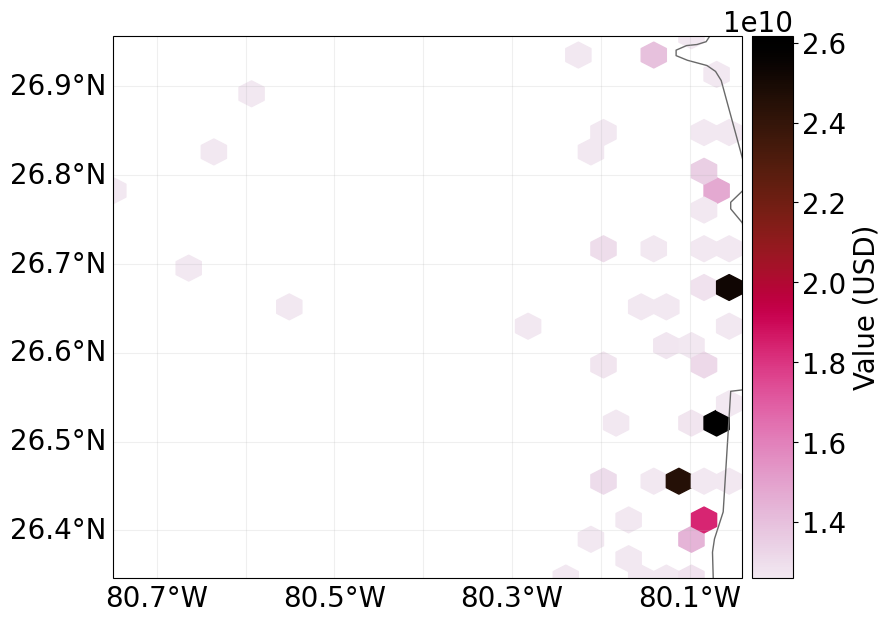

In [5]:
print(f"Valeur totale exposée (bâti) : {ent.exposures.gdf['value'].sum():,.0f} USD")
ent.exposures.plot_hexbin()

## 3. Calculer la perte (Impact)

`ImpactCalc` croise les 3 briques : pour chaque événement, pour chaque point exposé, il regarde l'intensité du hazard à cet endroit, applique la fonction de vulnérabilité pour en déduire un % de dommage, puis multiplie par la valeur exposée. Le résultat est sommé sur toute la grille pour chaque événement, ce qui donne une distribution de pertes possibles (une par événement simulé).

In [6]:
impact = ImpactCalc(ent.exposures, ent.impact_funcs, haz).impact()

print(f"Perte annuelle moyenne attendue (AAI - Average Annual Impact) : {impact.aai_agg:,.0f} USD")
print(f"Perte la plus sévère parmi les {haz.event_id.size} événements simulés : {impact.at_event.max():,.0f} USD")

Perte annuelle moyenne attendue (AAI - Average Annual Impact) : 76,747,879 USD
Perte la plus sévère parmi les 216 événements simulés : 4,854,902,223 USD


## 4. Courbe de dépassement (Exceedance Frequency Curve)

C'est LE graphique de référence en assurance/réassurance. Il répond à la question : "quelle est la perte qu'on a X% de chances de dépasser dans une année donnée ?" (ou, formulé autrement, "quelle est la perte associée à un événement de retour 100 ans, 250 ans, etc."). Axe X = période de retour (en années), axe Y = perte associée.

<Axes: title={'center': 'Exceedance frequency curve'}, xlabel='Return period (year)', ylabel='Impact (USD)'>

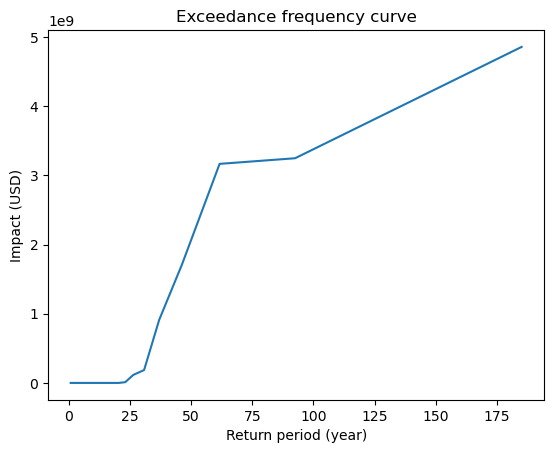

In [7]:
freq_curve = impact.calc_freq_curve()
freq_curve.plot()